# AICE 모의고사 4회 - 기후 변화 예측

## 문제 시나리오

과거 기상 정보 및 환경 데이터를 분석 및 전처리한 후 머신러닝과 딥러닝으로 특정 지역의 연간 평균 기온을 변화를 예측하고 결과를 분석하세요.

---

## 4-1 | 라이브러리 임포트 및 데이터 로딩

### 【 문제 】

- 필요한 패키지를 임포트 pandas 라이브러리를 pd라는 별칭으로 임포트하고, 두 개의 데이터를 분석에 활용하는 코드를 작성하세요.
- climate_data.json 파일을 읽어 데이터프레임 변수 df_climate에 할당하세요.
- pollution_data.csv 파일을 읽어 데이터프레임 변수 df_pollution에 할당하세요.


In [87]:
import pandas as pd

In [88]:
df_climate = pd.read_json('C:/juehyeon/aice_test/기출문제/4.기후변화예측/climate_data.json')

In [89]:
df_pollution = pd.read_csv('C:/juehyeon/aice_test/기출문제/4.기후변화예측/pollution_data.csv')

## 4-2 | 데이터 병합 및 초기 탐색

### 【 문제 】

- 두 개의 데이터프레임(df_climate, df_pollution)을 LocationID와 Year 컬럼을 기준으로 병합하고, 병합된 데이터프레임의 상위 5개 행과 컬럼별 요약 정보를 출력하여 초기 데이터를 탐색하는 코드를 작성하세요.
- pandas의 merge 함수를 사용하여 df_climate와 df_pollution을 LocationID와 Year를 키(key)로 병합하고 df 변수에 저장하세요.
- 병합 방식은 inner로 지정하세요.
- df 데이터프레임의 상위 5개 행을 출력하세요.
- df 데이터프레임의 컬럼별 정보(dtype, Non-null Count)를 확인하세요.

In [90]:
df = pd.merge(df_climate, df_pollution, on = ['LocationID', 'Year'], how = 'inner')

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   LocationID                41 non-null     int64  
 1   Year                      41 non-null     int64  
 2   AvgTemperature_C          41 non-null     float64
 3   CO2_Concentration_ppm     41 non-null     int64  
 4   SeaLevel_mm               40 non-null     float64
 5   ForestArea_percent        41 non-null     float64
 6   UrbanArea_percent         41 non-null     float64
 7   MajorEvent                41 non-null     object 
 8   PM25_ug_m3                41 non-null     float64
 9   Ozone_ppb                 41 non-null     float64
 10  IndustrialEmissions_tons  41 non-null     int64  
dtypes: float64(6), int64(4), object(1)
memory usage: 3.7+ KB


In [92]:
df.head()

,LocationID,Year,AvgTemperature_C,CO2_Concentration_ppm,SeaLevel_mm,ForestArea_percent,UrbanArea_percent,MajorEvent,PM25_ug_m3,Ozone_ppb,IndustrialEmissions_tons
0,16,2012,15.43,592,2.7,58.4,32.3,Flood,63.7,65.4,1488
1,8,2021,27.74,450,3.4,53.2,37.5,Flood,52.8,69.1,8099
2,17,2016,29.53,403,1.6,30.5,33.5,Storm,38.3,21.2,45298
3,5,2019,29.67,446,1.8,37.9,36.3,Storm,74.5,63.2,33376
4,5,2019,29.67,446,1.8,37.9,36.3,Storm,20.6,94.4,13329


## 4-3 | 범주형 변수 로트 시각화 및 데이터 경제

### 【 문제 】

- MajorEvent 컬럼의 분포를 시각화하고, 데이터 경제를 위해 'Unknown' 값을 가진 행을 제거하는 코드를 작성하세요.
- seaborn 라이브러리의 countplot을 사용하여 MajorEvent 컬럼의 분포를 시각화하세요.
- MajorEvent 컬럼 값이 'Unknown'인 행을 데이터프레임에서 삭제하세요.

In [93]:
import seaborn as sns

<Axes: xlabel='MajorEvent', ylabel='count'>

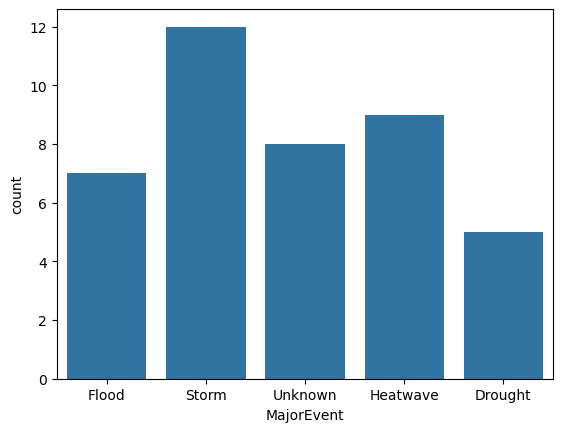

In [94]:
sns.countplot(data = df, x = 'MajorEvent')

In [95]:
df = df[df['MajorEvent'] != 'Unknown']

## 4-4 | 수치형 변수 관계 시각화 및 이상치 탐색

### 【 문제 】

- CO2_Concentration_ppm과 AvgTemperature_C 간의 관계를 jointplot으로 시각화하고, CO2_Concentration_ppm가 500 이상인 이상치를 찾아 행의 개수를 확인하는 코드를 작성하세요.
- seaborn 라이브러리의 jointplot을 사용하여 x축에 CO2_Concentration_ppm, y축에 AvgTemperature_C를 표시하세요.
- CO2_Concentration_ppm가 500 이상인 행의 개수를 세어 출력하세요.

In [96]:
import matplotlib.pyplot as plt

<Figure size 800x500 with 0 Axes>

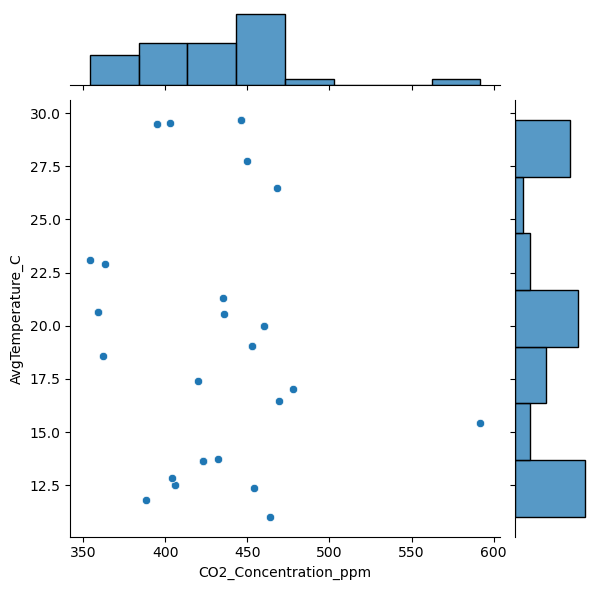

In [97]:
plt.figure(figsize = (8, 5))
sns.jointplot(
    data = df, 
    x = 'CO2_Concentration_ppm',
    y = 'AvgTemperature_C'
)
plt.xlabel('CO2_Concentration_ppm')
plt.ylabel('AvgTemperature_C')
plt.show()

In [98]:
row_count = df[df['CO2_Concentration_ppm'] >= 500].shape[0]

In [99]:
print(row_count)

1



## 4-5 | 이상치 및 불필요 컬럼 처리

### 【 문제 】

- CO2_Concentration_ppm가 500 이상인 이상치 행을 삭제하고, 모델링에 불필요한 LocationID와 Year 컬럼을 삭제하는 코드를 작성하세요.
- CO2_Concentration_ppm가 500 미만인 행만 남기고 데이터프레임을 업데이트하세요.
- LocationID와 Year 컬럼을 데이터프레임에서 삭제하세요.
- 변경된 데이터프레임을 df_cleaned에 저장하세요.


In [100]:
df = df[df['CO2_Concentration_ppm'] < 500]

In [101]:
df_cleaned = df.drop(columns = ['LocationID', 'Year']).copy()

In [102]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, 1 to 40
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   AvgTemperature_C          32 non-null     float64
 1   CO2_Concentration_ppm     32 non-null     int64  
 2   SeaLevel_mm               32 non-null     float64
 3   ForestArea_percent        32 non-null     float64
 4   UrbanArea_percent         32 non-null     float64
 5   MajorEvent                32 non-null     object 
 6   PM25_ug_m3                32 non-null     float64
 7   Ozone_ppb                 32 non-null     float64
 8   IndustrialEmissions_tons  32 non-null     int64  
dtypes: float64(6), int64(2), object(1)
memory usage: 2.5+ KB


## 4-6 | 결측치 처리 및 데이터 타입 변환

### 【 문제 】

- 데이터프레임에 결측치가 있는지 확인하고, 결측치가 있는 행을 삭제한 뒤, SeaLevel_mm 컬럼을 정수형(int)으로 변환하세요.
- df_cleaned의 결측치를 확인하는 코드를 작성하세요.

In [103]:
df_cleaned.isna().sum()

AvgTemperature_C            0
CO2_Concentration_ppm       0
SeaLevel_mm                 0
ForestArea_percent          0
UrbanArea_percent           0
MajorEvent                  0
PM25_ug_m3                  0
Ozone_ppb                   0
IndustrialEmissions_tons    0
dtype: int64

In [104]:
df_cleaned = df_cleaned.dropna()
df_cleaned['SeaLevel_mm'] = df_cleaned['SeaLevel_mm'].astype(int)

## 4-7 | 불필요 컬럼 처리 및 범주형 변수 원-핫 인코딩

### 【 문제 】

- UrbanArea_percent 컬럼을 삭제하고, object 타입의 범주형 컬럼(MajorEvent)을 원-핫 인코딩하세요.
- df_cleaned에서 UrbanArea_percent 컬럼을 삭제하세요.
- pandas의 get_dummies 함수를 활용하여 object 타입의 컬럼에 대해 원-핫 인코딩을 수행하세요.
- 변경된 결과를 df_encoded 변수에 저장하세요.

In [105]:
df_cleaned = df_cleaned.drop(columns='UrbanArea_percent')
df_cleaned = pd.get_dummies(df_cleaned, columns=['MajorEvent'])

In [106]:
df_cleaned.head()

,AvgTemperature_C,CO2_Concentration_ppm,SeaLevel_mm,ForestArea_percent,PM25_ug_m3,Ozone_ppb,IndustrialEmissions_tons,MajorEvent_Drought,MajorEvent_Flood,MajorEvent_Heatwave,MajorEvent_Storm
1,27.74,450,3,53.2,52.8,69.1,8099,False,True,False,False
2,29.53,403,1,30.5,38.3,21.2,45298,False,False,False,True
3,29.67,446,1,37.9,74.5,63.2,33376,False,False,False,True
4,29.67,446,1,37.9,20.6,94.4,13329,False,False,False,True
5,29.67,446,1,37.9,35.4,72.3,15818,False,False,False,True


In [107]:
df_encoded = df_cleaned.copy()


## 4-8 | 데이터 분리 및 스케일링

### 【 문제 】

- 최종 기온(AvgTemperature_C)을 예측하기 위해 데이터를 훈련 및 검증 데이터로 분리하고, 스케일링을 수행하세요.
- AvgTemperature_C 컬럼을 y 변수에, 나머지 컬럼을 X 변수에 할당하세요.
- scikit-learn의 train_test_split 함수를 사용하여 X와 y를 훈련 데이터(80%)와 검증 데이터(20%)으로 분리하세요. random_state는 42로 설정하세요.
- sklearn.preprocessing의 StandardScaler를 사용하여 훈련 데이터와의 Feature(X_train)를 스케일링하고 X_train_scaled에 할당하세요.
- StandardScaler의 transform 함수를 사용하여 검증 데이터와의 Feature(X_valid)를 스케일링하고 X_valid_scaled에 할당하세요.

In [108]:
X = df_encoded.drop(columns = 'AvgTemperature_C')

In [109]:
y = df_encoded['AvgTemperature_C']

In [110]:
from sklearn.model_selection import train_test_split

In [111]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, random_state = 42, test_size = 0.2)

In [112]:
from sklearn.preprocessing import StandardScaler

In [113]:
ss = StandardScaler()

In [114]:
X_train_scaled = ss.fit_transform(X_train)
X_valid_scaled = ss.transform(X_valid)

## 4-9 | 머신러닝 모델 학습(Random Forest Regressor)

### 【 문제 】

- scikit-learn의 RandomForestRegressor 모델을 생성하고 학습하세요.
- 모델의 n_estimators는 100, max_depth는 5, random_state는 42로 설정하세요.
- 모델을 rfr_model 변수에 저장하고, 훈련 데이터(X_train_scaled, y_train)으로 학습을 진행하세요.

In [115]:
from sklearn.ensemble import RandomForestRegressor

In [116]:
rfr_model = RandomForestRegressor(n_estimators = 100, max_depth = 5, random_state = 42)

In [117]:
rfr_model.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 4-10 | 머신러닝 모델 학습(Support Vector Regressor)

### 【 문제 】

- scikit-learn의 SVR(Support Vector Regressor) 모델을 생성하고 학습하세요.
- 모델의 커널(kernel)은 rbf, C는 10, gamma는 auto로 설정하세요.
- 모델을 svr_model 변수에 저장하고, 훈련 데이터(X_train_scaled, y_train)으로 학습을 진행하세요.

In [118]:
from sklearn.svm import SVR

In [119]:
svr_model = SVR(kernel = 'rbf', C = 10, gamma = 'auto')

In [120]:
svr_model.fit(X_train_scaled, y_train)

,kernel,'rbf'
,degree,3
,gamma,'auto'
,coef0,0.0
,tol,0.001
,C,10
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


## 4-11 | 머신러닝 모델 성능 평가(MAE 비교)

### 【 문제 】

- 두 머신러닝 모델(rfr_model, svr_model)의 성능을 검증 데이터를 사용하여 MAE(Mean Absolute Error)로 평가하고, 더 우수한 성능을 보인 모델의 이름을 answer11 변수에 저장하세요.
- rfr_model과 svr_model을 사용하여 검증 데이터(X_valid_scaled)에 대한 예측 값을 각각 rfr_pred, svr_pred에 저장하세요.
- scikit-learn의 mean_absolute_error 함수를 사용하여 두 모델의 MAE를 계산하고 각각 rfr_mae, svr_mae에 저장하세요.
- 두 MAE 값을 비교하여 더 작은 값을 가진 모델의 이름을 answer11 변수에 저장하세요(예: 'RandomForestRegressor', 'SVR')에 저장하세요.

In [121]:
from sklearn.metrics import mean_absolute_error

In [122]:
rfr_pred = rfr_model.predict(X_valid_scaled)
svr_pred = svr_model.predict(X_valid_scaled)

In [123]:
rfr_mae = mean_absolute_error(y_valid, rfr_pred)
svr_mae = mean_absolute_error(y_valid, svr_pred)

In [124]:
print(rfr_mae, '\n', svr_mae)

5.760513886787813 
 4.727241541812589


In [125]:
answer11 = 'SVR'

## 4-12 | 딥러닝 모델 개발 및 학습

### 【 문제 】

- tensorflow.keras를 사용하여 AvgTemperature_C를 예측하는 딥러닝 모델을 만들고 학습하세요.
- 히든 레이어(Hidden Layer)를 2개 이상으로 구성하세요.
- Dropout 레이어를 1개 추가하고 비율을 0.2로 설정하세요.
- 손실 함수(loss function)는 mean_squared_error를 사용하세요.
- epochs는 30, batch_size는 16으로 설정하세요.
- 학습 과정에서 검증 데이터셋(X_valid_scaled, y_valid)을 사용하여 성능을 평가하고, 학습 정보를 history 변수에 저장하세요.

In [126]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout, Input, Dense

In [127]:
model = Sequential([
    Input(shape = (X_train_scaled.shape[1],)),
    Dense(64, activation = 'relu'),
    Dropout(0.2),
    Dense(32, activation = 'relu'),
    Dense(1)
])

model.compile(optimizer = 'adam', loss = 'mean_squared_error')

In [128]:
history = model.fit(X_train_scaled, y_train, epochs = 30, batch_size = 16, validation_data = (X_valid_scaled, y_valid))

Epoch 1/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 351ms/step - loss: 474.2679 - val_loss: 294.1920
Epoch 2/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 472.1609 - val_loss: 290.5949
Epoch 3/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 463.6878 - val_loss: 287.0325
Epoch 4/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 457.8223 - val_loss: 283.4331
Epoch 5/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - loss: 452.9921 - val_loss: 279.8088
Epoch 6/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 446.6695 - val_loss: 276.2310
Epoch 7/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 442.2395 - val_loss: 272.5703
Epoch 8/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 435.8591 - val_loss: 268.8354
Epoch 9/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 432.8970 - val_loss: 264.9676
Epoch 10/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 424.9523 - val_loss: 261.0275
Epoch 11/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 419.4120 - val_loss: 256.9536
Epoch 12/30
2/2 ━━━━━━━━━━━━━━━━━━━

## 4-13 | 딥러닝 모델 학습 성능 시각화

### 【 문제 】

- matplotlib을 활용하여 딥러닝 모델의 학습 MSE와 검증 MSE를 그래프로 표시하고, 반복에 축 레이블을 추가하여 성능 변화를 시각화하세요.
- history 변수에 저장된 학습 MSE(loss)와 검증 MSE(val_loss)를 그래프로 그리세요.
- 각각의 변화를 'Training MSE'와 'Validation MSE'로 표시하세요.
- x축에 'Epochs', y축에 'MSE'라는 레이블을 지정하세요.

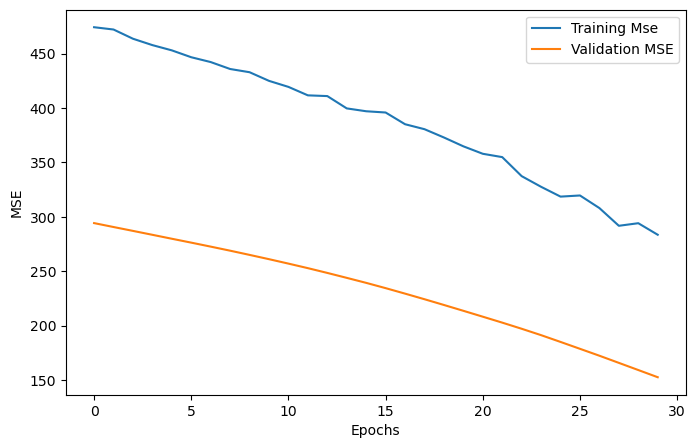

In [129]:
plt.figure(figsize = (8, 5))
plt.plot(history.history['loss'], label = 'Training Mse')
plt.plot(history.history['val_loss'], label = 'Validation MSE')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.show()


4-14 | IQR 기반 이상치 재탐지
【 문제 】

기존에는 CO2_Concentration_ppm ≥ 500을 고정 기준으로 이상치를 제거했습니다. 이번엔 IQR(Interquartile Range) 방법으로 같은 컬럼의 이상치를 재탐지하세요.
이 기준으로 이상치 행이 몇 개인지 출력하세요.
(생각해볼 점: 고정 임계값(500)과 IQR 기준의 결과가 같은지 다른지 비교해보세요.)

In [131]:
Q1 = df_cleaned['CO2_Concentration_ppm'].quantile(0.25)
Q3 = df_cleaned['CO2_Concentration_ppm'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [132]:
outliers = df_cleaned[(df_cleaned['CO2_Concentration_ppm'] < lower, 
                       df_cleaned['CO2_Concentration_ppm'] > upper)]

InvalidIndexError: (1     False
2     False
3     False
4     False
5     False
7     False
8     False
9     False
10    False
12    False
13    False
15    False
16    False
18    False
19    False
21    False
22    False
23    False
24    False
25    False
26    False
27    False
28    False
29    False
30    False
31    False
32    False
33    False
34    False
36    False
38    False
40    False
Name: CO2_Concentration_ppm, dtype: bool, 1     False
2     False
3     False
4     False
5     False
7     False
8     False
9     False
10    False
12    False
13    False
15    False
16    False
18    False
19    False
21    False
22    False
23    False
24    False
25    False
26    False
27    False
28    False
29    False
30    False
31    False
32    False
33    False
34    False
36    False
38    False
40    False
Name: CO2_Concentration_ppm, dtype: bool)